<a href="https://colab.research.google.com/github/Feranmi149/OIBSIP/blob/main/TASK_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
import datetime as dt

In [4]:
reference_date = df['Date'].max() + dt.timedelta(days=1)


In [5]:
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (reference_date - x.max()).days,
    'Transaction ID': 'count',
    'Total Amount': 'sum'
})


In [6]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,39,1,150
CUST002,309,1,1000
CUST003,354,1,30
CUST004,226,1,500
CUST005,241,1,100


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

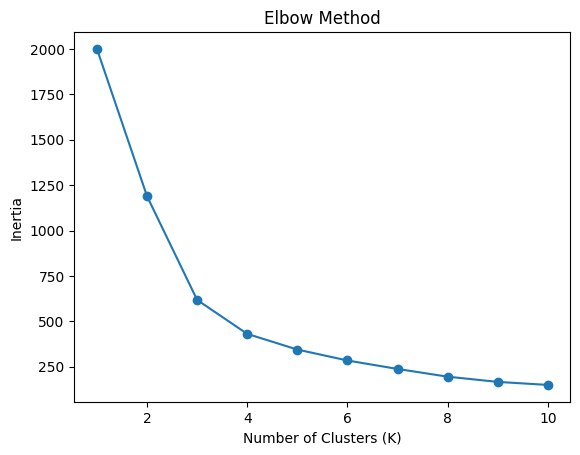

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The elbow curve shows a sharp drop from K=1 to K=3, after which the curve flattens significantly. This bend at K=4 suggests 4 clusters is the optimal choice thereby capturing meaningful customer groupings without over-splitting the data into unnecessary segments.

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
CUST001,39,1,150,1
CUST002,309,1,1000,0
CUST003,354,1,30,2
CUST004,226,1,500,2
CUST005,241,1,100,2


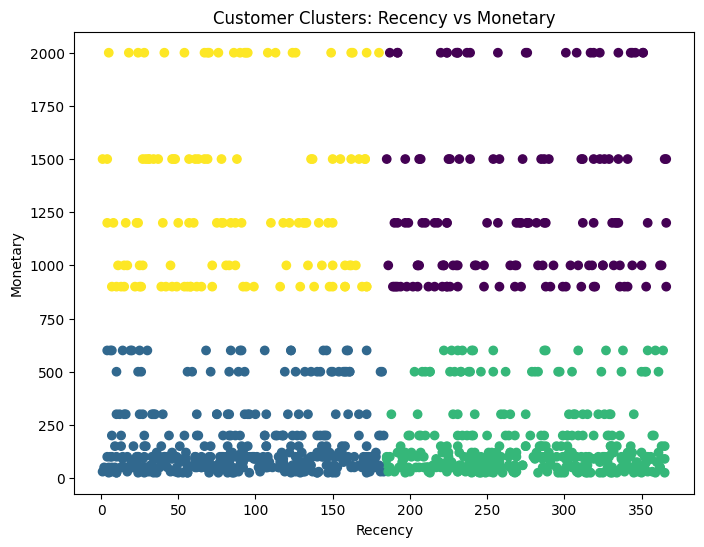

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Recency vs Monetary')
plt.show()

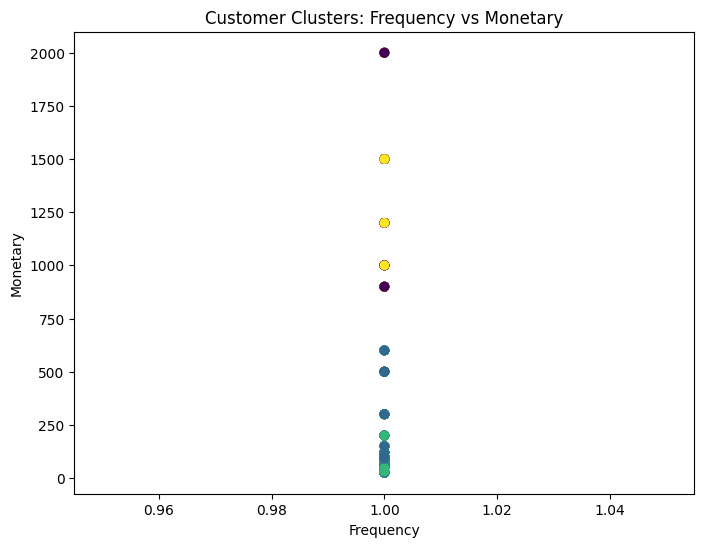

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.show()

In [12]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,270.521429,1.0,1283.571429
1,92.116216,1.0,159.770270
2,274.573770,1.0,148.319672
3,84.935484,1.0,1313.709677


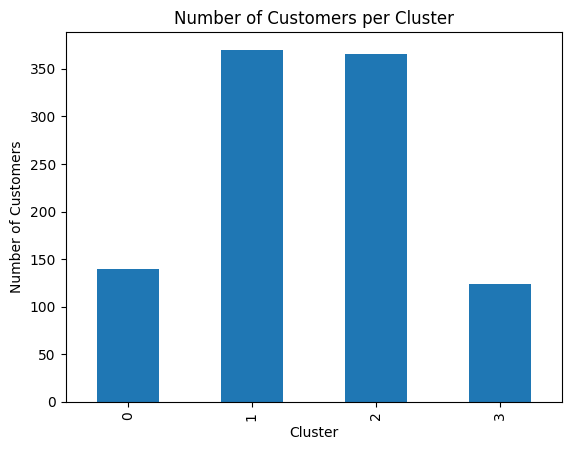

In [13]:
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', title='Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

Cluster Profiles:

Cluster 3: "Champions": Recently active, high spenders. Smallest group but most valuable retain and reward with loyalty perks.
Cluster 0: "At-Risk High Spenders": High spending history but haven't purchased in a long time [avg. 270 days]. Strong win-back candidates targeted discount or re-engagement email could recover significant revenue.
Cluster 1: "Recent Low Spenders": Purchased recently but at low value. Largest segment/good candidates for upselling or bundle offers to increase order value.
Cluster 2: "Inactive Low-Value": Haven't purchased in a long time and spent little when they did. Lowest priority for marketing spend, though a low-cost reactivation campaign could test interest.

Note: Frequency is 1.0 across all clusters because each customer in this dataset made only a single transaction, so the segmentation is driven entirely by Recency and Monetary value.

Marketing Recommendations by Segment:

Champions (Cluster 3): Offer loyalty rewards or early access to new products to keep them engaged.
At-Risk High Spenders (Cluster 0): Send a personalized "we miss you" campaign with a meaningful discount to win them back before they churn completely.
Recent Low Spenders (Cluster 1): Use cross-sell/upsell tactics (e.g., "customers like you also bought...") to increase their average order value.
Inactive Low-Value (Cluster 2): Deprioritize heavy spend here; a low-cost email nudge is reasonable, but don't over-invest in this segment.